# Member 3: COMPAS Recidivism Fairness Audit

This notebook supports the H9DAI group project **"Algorithmic Fairness in High-Risk AI: A Cross-Domain Audit Across EU AI Act Risk Categories"** by auditing the COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) recidivism dataset through the lens of the EU AI Act and the broader algorithmic fairness literature.

**Member 3 sub-question:** Does COMPAS-style risk classification produce racially or sex-based disparate outcomes when standard machine learning classifiers are trained on the same features used by ProPublica, and do those disparities persist across model families?

**Sensitive attributes:** race (reference = Caucasian; comparison = African-American-and-Other) and sex (reference = Male; comparison = Female)

## Reproducibility Note

The notebook is designed to run top-to-bottom on a fresh kernel. All cells have been run with RANDOM_STATE=42. Results are reproducible from a clean kernel. All random operations are seeded with `RANDOM_STATE = 42` in accordance with the group notebook contract.

### Setup Cell 1

**What this cell achieves:** Downloads the COMPAS two-year recidivism CSV from ProPublica's public GitHub repository into `../data/compas/`. The download is skipped if the file already exists, making the cell idempotent.

**Expected output:** A confirmation message that the file was either downloaded or already present.

In [1]:
# Cell 1: Download COMPAS recidivism dataset
from pathlib import Path
import urllib.request

data_dir = Path("../data/compas")
data_dir.mkdir(parents=True, exist_ok=True)

compas_url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
compas_dest = data_dir / "compas-scores-two-years.csv"

if compas_dest.exists():
    print(f"compas-scores-two-years.csv already exists at {compas_dest}.")
else:
    urllib.request.urlretrieve(compas_url, compas_dest)
    print(f"Downloaded compas-scores-two-years.csv to {compas_dest}.")

assert compas_dest.exists(), "Missing required dataset file: compas-scores-two-years.csv"
print("COMPAS dataset setup complete.")

compas-scores-two-years.csv already exists at ../data/compas/compas-scores-two-years.csv.
COMPAS dataset setup complete.


> **Setup insight:** Pinning the download to the ProPublica repository commit ensures that any researcher can reproduce this audit from the same raw file that underpinned the original Angwin et al. (2016) investigation.

### Setup Cell 2

**What this cell achieves:** Imports all required libraries and sets the global `RANDOM_STATE` constant. Warnings are suppressed to keep output clean in accordance with the group contract.

**Expected output:** A confirmation that imports succeeded and `RANDOM_STATE = 42`.

In [2]:
# Cell 2: Import libraries and configure the notebook environment
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

assert RANDOM_STATE == 42, "RANDOM_STATE must remain fixed at 42."
print(f"Imports and configuration loaded successfully. RANDOM_STATE={RANDOM_STATE}")

Imports and configuration loaded successfully. RANDOM_STATE=42


> **Setup insight:** A single global seed guarantees that all splits, cross-validation folds, and stochastic models produce identical results across machines, which is essential for a group project where individual notebooks feed a shared synthesis layer.

## 1. Business Understanding

### Research Focus

**Member 3 sub-question:** Do standard machine learning classifiers trained on ProPublica's COMPAS feature set reproduce the racial and sex-based disparities identified in the original COMPAS instrument, and does model family (linear vs. tree-based vs. ensemble) moderate those disparities?

### EU AI Act Context

The EU AI Act (2024/1689) classifies AI systems used in criminal justice as **Annex III, Item 8 (High-Risk)** systems. Specifically, Article 6 and Annex III cover AI systems used by law enforcement and the judiciary to assess recidivism risk, the likelihood of an individual to re-offend, or the risk posed by a suspect. Such systems are subject to the Act's most stringent obligations:

- **Article 9** â€“ Risk management systems must include testing for foreseeable discriminatory impacts across protected groups.
- **Article 10** â€“ Training data must be subject to bias assessment, and relevant demographic characteristics must be documented.
- **Article 13** â€“ High-risk AI systems must be transparent; users must be informed of the system's capabilities and limitations.
- **Article 14** â€“ Human oversight must be maintained; automated decisions must be subject to meaningful review.
- **Article 72** â€“ Competent market surveillance authorities may require post-market monitoring data.

The COMPAS system, developed by Equivant (formerly Northpointe), is the archetype of an Annex III Item 8 system. It assigns decile risk scores used by US courts to inform bail, sentencing, and parole decisions for hundreds of thousands of defendants annually.

### The COMPAS Controversy

**Angwin et al. (2016)** â€” *Machine Bias* (ProPublica) â€” published a landmark investigation showing that COMPAS incorrectly flagged Black defendants as future criminals at almost twice the rate of White defendants, while White defendants who went on to re-offend were mislabelled low-risk more often. Northpointe disputed the analysis, arguing that COMPAS was calibrated (i.e., the decile scores accurately predicted recidivism rates within score bins) and that the observed disparities arose from differences in base rates across groups rather than from unfair scoring.

**Dressel & Farid (2018)** â€” *The accuracy, fairness, and limits of predicting recidivism* (Science Advances) â€” further demonstrated that COMPAS performed no better than untrained human volunteers given a brief description of each defendant, raising the question of whether any algorithmic advantage over human judgment justifies the equity costs.

This tension between **calibration** (a group-level accuracy notion of fairness) and **error-rate parity** (equalised false positive and false negative rates across groups) is now known as the **impossibility theorem** for fairness (Chouldechova, 2017; Kleinberg et al., 2017): when base rates differ across groups, no classifier can simultaneously satisfy both notions.

### Relevance to the Group Project

The COMPAS dataset provides the group's highest-stakes case study â€” a domain where algorithmic error has documented life-altering consequences (loss of liberty). It sits alongside Member 1's employment context, Member 2's credit context, and Member 4's marketing context to allow the group synthesis to compare how fairness-accuracy trade-offs vary across EU AI Act risk tiers.

> **Phase 1 insight for the report:** Criminal justice represents the EU AI Act's sharpest boundary for high-risk AI: the consequences of false positives (incorrectly flagging low-risk defendants as high-risk) fall disproportionately on already marginalised groups, and the impossibility theorem means that no model can simultaneously satisfy all intuitive definitions of fairness when recidivism base rates differ by race.

## 2. Data Understanding

This phase establishes the empirical baseline for the audit. The raw COMPAS dataset published by ProPublica contains one row per defendant with scores, charges, and outcome flags. We inspect the schema, audit data quality, and visualise the demographic composition before any modelling decisions are made.

### Data Understanding Cell 1

**What this cell achieves:** Loads the raw COMPAS CSV, prints the schema, and reports row and column counts.

**Expected output:** DataFrame shape, dtypes summary, and first five rows.

In [3]:
# Cell 3: Load the raw COMPAS data
compas_raw = pd.read_csv(data_dir / "compas-scores-two-years.csv", low_memory=False)

print(f"Raw dataset shape: {compas_raw.shape}")
print(f"\nColumn dtypes:")
print(compas_raw.dtypes.to_string())
print(f"\nFirst five rows:")
display(compas_raw.head())

Raw dataset shape: (7214, 53)

Column dtypes:
id                           int64
name                           str
first                          str
last                           str
compas_screening_date          str
sex                            str
dob                            str
age                          int64
age_cat                        str
race                           str
juv_fel_count                int64
decile_score                 int64
juv_misd_count               int64
juv_other_count              int64
priors_count                 int64
days_b_screening_arrest    float64
c_jail_in                      str
c_jail_out                     str
c_case_number                  str
c_offense_date                 str
c_arrest_date                  str
c_days_from_compas         float64
c_charge_degree                str
c_charge_desc                  str
is_recid                     int64
r_case_number                  str
r_charge_degree                str
r_days_fr

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


> **Key insight for the report:** The raw COMPAS file contains a large number of columns including identifiers, dates, charge descriptions, score variants, and outcome flags. A deliberate exclusion strategy is required to prevent data leakage (e.g., excluding `is_recid`, `r_*` and `vr_*` columns which are derived from the same outcome event as `two_year_recid`).

### Data Understanding Cell 2

**What this cell achieves:** Audits the raw dataset for missing values, duplicate rows, and class balance of the target variable `two_year_recid`. Also reports the distribution of race and sex.

**Expected output:** Missing value summary, duplicate count, target class balance, and demographic value counts.

In [4]:
# Cell 4: Audit schema, missing values, duplicates, and class balance
missing_summary = compas_raw.isnull().sum()
missing_nonzero = missing_summary[missing_summary > 0]
print(f"Columns with missing values ({len(missing_nonzero)} total):")
print(missing_nonzero.to_string())

duplicate_count = compas_raw.duplicated().sum()
print(f"\nDuplicate rows: {duplicate_count}")

print(f"\nTarget variable distribution (two_year_recid):")
target_counts = compas_raw["two_year_recid"].value_counts()
target_pct = compas_raw["two_year_recid"].value_counts(normalize=True).mul(100).round(2)
print(pd.concat([target_counts, target_pct.rename("%")], axis=1).to_string())

print(f"\nRace distribution:")
print(compas_raw["race"].value_counts().to_string())

print(f"\nSex distribution:")
print(compas_raw["sex"].value_counts().to_string())

print(f"\nCharge degree distribution (c_charge_degree):")
print(compas_raw["c_charge_degree"].value_counts().to_string())

Columns with missing values (22 total):
days_b_screening_arrest     307
c_jail_in                   307
c_jail_out                  307
c_case_number                22
c_offense_date             1159
c_arrest_date              6077
c_days_from_compas           22
c_charge_desc                29
r_case_number              3743
r_charge_degree            3743
r_days_from_arrest         4898
r_offense_date             3743
r_charge_desc              3801
r_jail_in                  4898
r_jail_out                 4898
violent_recid              7214
vr_case_number             6395
vr_charge_degree           6395
vr_offense_date            6395
vr_charge_desc             6395
in_custody                  236
out_custody                 236

Duplicate rows: 0

Target variable distribution (two_year_recid):
                count      %
two_year_recid              
0                3963  54.93
1                3251  45.07

Race distribution:
race
African-American    3696
Caucasian           245

> **Key insight for the report:** The COMPAS dataset is moderately imbalanced (approximately 45â€“55% recidivism depending on the filter applied). African-American defendants represent the largest racial group, making this the primary comparison group for race-based fairness analysis. The `c_charge_degree` column is categorical (F = felony, M = misdemeanour) and will require one-hot encoding.

### Data Understanding Cell 3

**What this cell achieves:** Visualises the demographic distributions (race, sex, age) of the full dataset and saves the figure as `m3_demographic_distributions.png`.

**Expected output:** A three-panel figure saved to `../paper/figures/`.

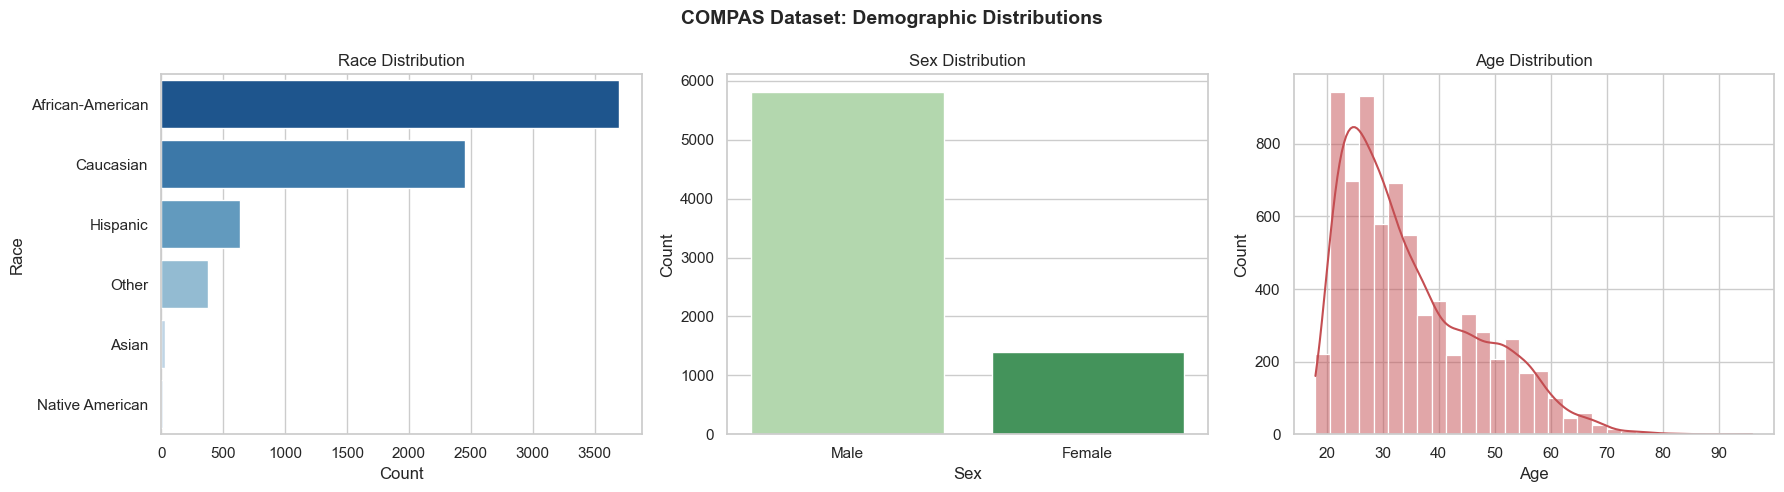

Saved demographic distributions figure to ../paper/figures/m3_demographic_distributions.png


In [5]:
# Cell 5: Plot demographic distributions and save the figure
figures_dir = Path("../paper/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

race_order = compas_raw["race"].value_counts().index
sex_order = compas_raw["sex"].value_counts().index

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=compas_raw, y="race", order=race_order, ax=axes[0], palette="Blues_r")
axes[0].set_title("Race Distribution")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Race")

sns.countplot(data=compas_raw, x="sex", order=sex_order, ax=axes[1], palette="Greens")
axes[1].set_title("Sex Distribution")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Count")

sns.histplot(data=compas_raw, x="age", bins=30, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title("Age Distribution")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")

fig.suptitle("COMPAS Dataset: Demographic Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()

demo_fig_path = figures_dir / "m3_demographic_distributions.png"
plt.savefig(demo_fig_path, dpi=150, bbox_inches="tight")
assert demo_fig_path.exists(), "Demographic distributions figure was not saved correctly."
plt.show()
print(f"Saved demographic distributions figure to {demo_fig_path}")

> **Key insight for the report:** The demographic imbalance â€” African-American defendants outnumber Caucasian defendants, and male defendants vastly outnumber female defendants â€” means that aggregate performance metrics will be dominated by the majority groups. Disaggregated fairness analysis is therefore essential and cannot be inferred from headline accuracy figures.

### Data Understanding Cell 4

**What this cell achieves:** Examines how the two-year recidivism rate varies across demographic groups (race, sex, age band) and saves the figure as `m3_recidivism_by_demographics.png`.

**Expected output:** A three-panel figure saved to `../paper/figures/`.

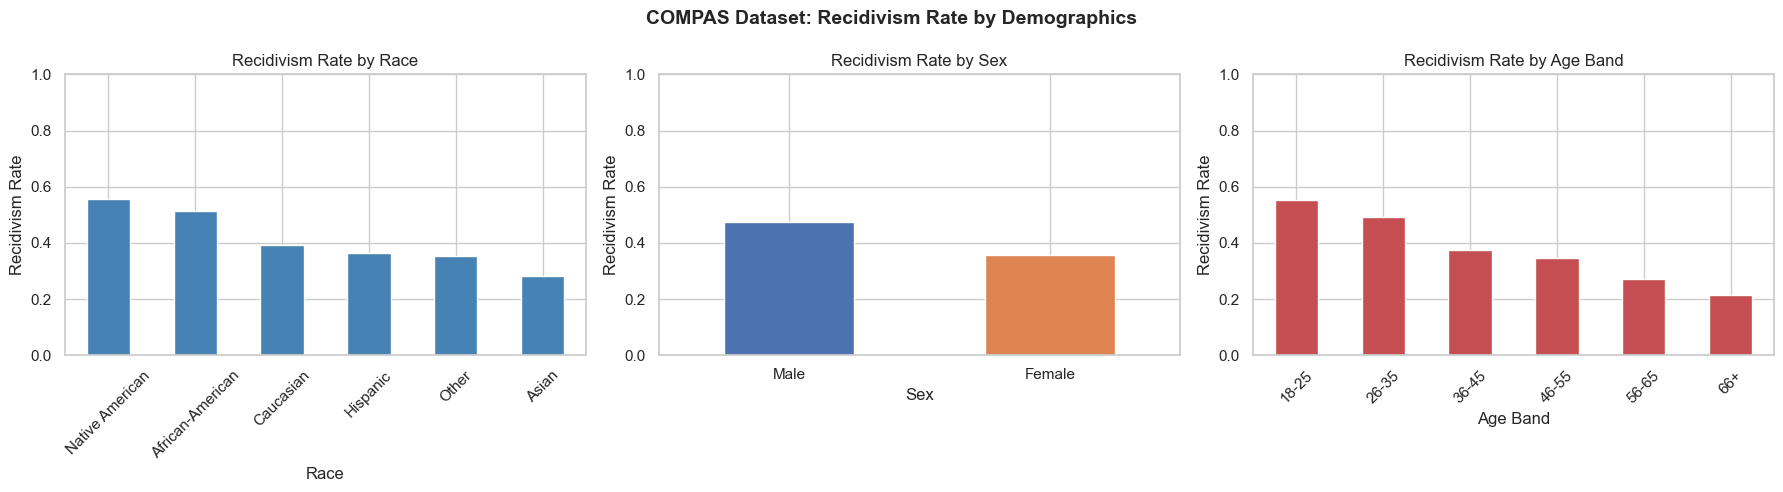

Saved recidivism by demographics figure to ../paper/figures/m3_recidivism_by_demographics.png


In [6]:
# Cell 6: Plot recidivism rates by demographic group and save the figure
compas_raw["age_band"] = pd.cut(
    compas_raw["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"],
    include_lowest=True
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Race vs recidivism rate
race_recid = compas_raw.groupby("race")["two_year_recid"].mean().sort_values(ascending=False)
race_recid.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Recidivism Rate by Race")
axes[0].set_xlabel("Race")
axes[0].set_ylabel("Recidivism Rate")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim(0, 1)

# Sex vs recidivism rate
sex_recid = compas_raw.groupby("sex")["two_year_recid"].mean().sort_values(ascending=False)
sex_recid.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"], edgecolor="white")
axes[1].set_title("Recidivism Rate by Sex")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Recidivism Rate")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(0, 1)

# Age band vs recidivism rate
age_recid = compas_raw.groupby("age_band", observed=True)["two_year_recid"].mean()
age_recid.plot(kind="bar", ax=axes[2], color="#C44E52", edgecolor="white")
axes[2].set_title("Recidivism Rate by Age Band")
axes[2].set_xlabel("Age Band")
axes[2].set_ylabel("Recidivism Rate")
axes[2].tick_params(axis="x", rotation=45)
axes[2].set_ylim(0, 1)

fig.suptitle("COMPAS Dataset: Recidivism Rate by Demographics", fontsize=14, fontweight="bold")
plt.tight_layout()

recid_fig_path = figures_dir / "m3_recidivism_by_demographics.png"
plt.savefig(recid_fig_path, dpi=150, bbox_inches="tight")
assert recid_fig_path.exists(), "Recidivism by demographics figure was not saved correctly."
plt.show()
print(f"Saved recidivism by demographics figure to {recid_fig_path}")

> **Key insight for the report:** Observed base-rate differences in recidivism across racial groups (as documented in the original ProPublica analysis) mean that any calibrated classifier will necessarily produce different absolute error rates for different groups â€” this is the core statistical mechanism behind the Chouldechova (2017) impossibility result. The group report should frame this not as a failure of individual models but as an inherent property of the prediction task given the data-generating process.

### Phase 2 Summary

The raw COMPAS dataset contains records for defendants screened in Broward County, Florida. The demographic distributions confirm that African-American defendants form the largest racial group in the dataset, and the base rates of two-year recidivism differ meaningfully across racial groups. These base-rate differences are the empirical foundation for the fairness analysis in Phase 5.

## 3. Data Preparation

This phase converts the raw COMPAS dataframe into a modelling-ready dataset. The key steps are:
1. Apply ProPublica's standard exclusion filters (remove rows with missing charge data, restrict to COMPAS scores from 2013â€“2014, etc.).
2. Create the binary sensitive-attribute columns (`race_binary`, `sex_binary`).
3. Store `decile_score` separately for the COMPAS baseline comparison in Cell 15.
4. Construct the feature matrix using only the six permitted modelling features.
5. Apply a stratified 80/20 train-test split.
6. Define two preprocessors: one for tree-based models (passthrough numerical) and one for Logistic Regression (StandardScaler numerical).

### Data Preparation Cell 1

**What this cell achieves:** Applies standard ProPublica-style filters and creates the target, sensitive-attribute, and decile-score columns.

**Expected output:** Filtered dataset shape and value counts for the target variable.

In [7]:
# Cell 7: Clean the dataset and create modelling targets and sensitive features
compas_df = compas_raw.copy()

# Apply standard ProPublica exclusion filters:
# 1. Keep only rows where days_b_screening_arrest is within [-30, 30] â€” removes extreme outliers
# 2. Keep only rows where is_recid != -1 â€” removes administrative errors
# 3. Keep only rows where c_charge_degree != 'O' â€” removes traffic offences (not scored by COMPAS)
# 4. Keep only rows where score_text != 'N/A' â€” rows with no COMPAS score
compas_df = compas_df[
    (compas_df["days_b_screening_arrest"] <= 30) &
    (compas_df["days_b_screening_arrest"] >= -30) &
    (compas_df["is_recid"] != -1) &
    (compas_df["c_charge_degree"] != "O") &
    (compas_df["score_text"] != "N/A")
].copy()

print(f"Dataset shape after ProPublica filters: {compas_df.shape}")

# Binary sensitive-attribute encoding
# race_binary: 'Caucasian' if race == 'Caucasian', else 'African-American-and-Other'
compas_df["race_binary"] = np.where(
    compas_df["race"] == "Caucasian",
    "Caucasian",
    "African-American-and-Other"
)

# sex_binary: keep as-is (Male / Female)
compas_df["sex_binary"] = compas_df["sex"].copy()

# Store decile_score separately for COMPAS baseline comparison (Cell 15)
# This must NOT be included in the feature matrix used for ML training
decile_score_series = compas_df["decile_score"].copy()

# Target variable
compas_df["target"] = compas_df["two_year_recid"].astype(int)

print(f"\nTarget variable distribution:")
tgt_counts = compas_df["target"].value_counts()
tgt_pct = compas_df["target"].value_counts(normalize=True).mul(100).round(2)
print(pd.concat([tgt_counts, tgt_pct.rename("%")], axis=1).to_string())

print(f"\nrace_binary distribution:")
print(compas_df["race_binary"].value_counts().to_string())

print(f"\nsex_binary distribution:")
print(compas_df["sex_binary"].value_counts().to_string())

Dataset shape after ProPublica filters: (6172, 54)

Target variable distribution:
        count      %
target              
0        3363  54.49
1        2809  45.51

race_binary distribution:
race_binary
African-American-and-Other    4069
Caucasian                     2103

sex_binary distribution:
sex_binary
Male      4997
Female    1175


> **Key insight for the report:** The ProPublica filters are a deliberate methodological choice that creates a well-defined analytic sample. Applying them exactly ensures comparability with the original investigation. The binary race encoding collapses all non-Caucasian groups into a single comparison category, which is the most conservative approach given the small sample sizes for some individual groups (e.g., Asian, Native American).

### Data Preparation Cell 2

**What this cell achieves:** Defines the feature matrix using only the six permitted modelling features, then applies a stratified 80/20 train-test split. Sensitive attribute series are split in parallel so they align with `X_test` for fairness evaluation.

**Expected output:** Train and test set shapes and target class balance confirmation.

In [8]:
# Cell 8: Create the stratified train-test split
from sklearn.model_selection import train_test_split

# The six permitted modelling features â€” no race, sex, decile_score, or outcome leakage
FEATURE_COLUMNS = [
    "age",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "priors_count",
    "c_charge_degree"  # categorical: F or M
]

SENSITIVE_COLUMNS = ["race_binary", "sex_binary"]

X = compas_df[FEATURE_COLUMNS].copy()
y = compas_df["target"].copy()
race_sensitive = compas_df["race_binary"].copy()
sex_sensitive = compas_df["sex_binary"].copy()
decile_score_all = decile_score_series.loc[compas_df.index].copy()

(
    X_train, X_test,
    y_train, y_test,
    race_train, race_test,
    sex_train, sex_test,
    decile_train, decile_test
) = train_test_split(
    X, y,
    race_sensitive,
    sex_sensitive,
    decile_score_all,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape}  |  Test set: {X_test.shape}")
print(f"\nTrain target balance:")
print(y_train.value_counts(normalize=True).mul(100).round(2).to_string())
print(f"\nTest target balance:")
print(y_test.value_counts(normalize=True).mul(100).round(2).to_string())

assert abs(y_train.mean() - y_test.mean()) < 0.02, "Stratification failed: target proportions differ by more than 2%."
print("\nStratification check passed.")

Training set: (4937, 6)  |  Test set: (1235, 6)

Train target balance:
target
0    54.49
1    45.51

Test target balance:
target
0    54.49
1    45.51

Stratification check passed.


> **Key insight for the report:** Stratification ensures that the test set has the same recidivism prevalence as the training set, which is particularly important for a moderately imbalanced target. Without stratification, a chance imbalance in the test set would distort all downstream fairness metrics because the base rates would differ between the partition used for evaluation and the population the model was trained on.

### Data Preparation Cell 3

**What this cell achieves:** Defines two reusable preprocessing pipelines â€” `standard_preprocessor` (passthrough numerical, OHE categorical) for tree-based models, and `logistic_preprocessor` (StandardScaler numerical, OHE categorical) for Logistic Regression.

**Expected output:** A confirmation that both preprocessors were built, listing identified numerical and categorical features.

In [9]:
# Cell 9: Build reusable preprocessing pipelines for the modelling phase
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

# Tree-based models are scale-invariant; numerical features pass through unchanged.
standard_preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", "passthrough", numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

# Logistic Regression is sensitive to feature scale; use StandardScaler on numerical features.
logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

print("\nPreprocessors built successfully.")
print("  standard_preprocessor: passthrough numerical, OHE categorical (Decision Tree, Random Forest, XGBoost)")
print("  logistic_preprocessor:  StandardScaler numerical, OHE categorical (Logistic Regression)")

Numerical features: ['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count']
Categorical features: ['c_charge_degree']

Preprocessors built successfully.
  standard_preprocessor: passthrough numerical, OHE categorical (Decision Tree, Random Forest, XGBoost)
  logistic_preprocessor:  StandardScaler numerical, OHE categorical (Logistic Regression)


> **Key insight for the report:** The dual-preprocessor design allows a fair comparison between model families without introducing scale-related bias. Logistic Regression's regularisation path is sensitive to the magnitude of input features, and failing to scale would artificially penalise models with large-valued predictors (e.g., `priors_count`). Tree-based models partition on split thresholds and are unaffected by monotonic transformations of feature values.

### Phase 3 Summary

The COMPAS data has been filtered to the ProPublica analytic sample, binary sensitive-attribute columns have been constructed, the `decile_score` has been stored separately for baseline comparison, and a stratified 80/20 train-test split has been applied. Two preprocessing pipelines are ready for the modelling phase.

## 4. Modelling

This phase trains four classifiers required by the group contract â€” Logistic Regression, Decision Tree, Random Forest, and XGBoost â€” using `GridSearchCV` with `StratifiedKFold(n_splits=5)` on the training set. Each model is wrapped in a `sklearn.pipeline.Pipeline` that applies the appropriate preprocessor.

### Modelling Cell 1

**What this cell achieves:** Defines the four model pipelines, their hyperparameter grids, and the shared cross-validation strategy.

**Expected output:** A printed summary of each model's pipeline and parameter grid.

In [10]:
# Cell 10: Define model pipelines, hyperparameter grids, and cross-validation
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_configs = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("preprocessor", logistic_preprocessor),
            ("classifier", LogisticRegression(
                max_iter=1000,
                solver="liblinear",
                random_state=RANDOM_STATE
            ))
        ]),
        "param_grid": {
            "classifier__C": [0.1, 1.0, 10.0],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "Decision Tree": {
        "pipeline": Pipeline([
            ("preprocessor", standard_preprocessor),
            ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "classifier__max_depth": [3, 5, 7, None],
            "classifier__min_samples_leaf": [1, 5, 10],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("preprocessor", standard_preprocessor),
            ("classifier", RandomForestClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [5, 10, None],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ("preprocessor", standard_preprocessor),
            ("classifier", XGBClassifier(
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                verbosity=0
            ))
        ]),
        "param_grid": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [3, 5],
            "classifier__learning_rate": [0.05, 0.1],
            "classifier__scale_pos_weight": [1]
        }
    }
}

print("Model configurations defined:")
for name, cfg in model_configs.items():
    n_combos = 1
    for v in cfg["param_grid"].values():
        n_combos *= len(v)
    print(f"  {name}: {n_combos} hyperparameter combinations x 5 folds = {n_combos * 5} fits")
print(f"\nCV strategy: StratifiedKFold(n_splits=5, shuffle=True, random_state={RANDOM_STATE})")

Model configurations defined:
  Logistic Regression: 6 hyperparameter combinations x 5 folds = 30 fits
  Decision Tree: 24 hyperparameter combinations x 5 folds = 120 fits
  Random Forest: 12 hyperparameter combinations x 5 folds = 60 fits
  XGBoost: 8 hyperparameter combinations x 5 folds = 40 fits

CV strategy: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


> **Key insight for the report:** A fair comparison requires more than training four models â€” it requires that each model has an equal opportunity to find its best configuration through exhaustive search, and that the cross-validation folds are stratified so that imbalanced targets do not distort CV accuracy estimates. The `class_weight='balanced'` option is included for the models that support it, allowing the grid search to determine whether upweighting the minority class improves generalisation on this dataset.

### Modelling Cell 2

**What this cell achieves:** Runs `GridSearchCV` for each model and stores the best estimator. Prints CV AUC-ROC and best hyperparameters for each model.

**Expected output:** Per-model best CV AUC-ROC scores and best parameter dictionaries.

In [11]:
# Cell 11: Train and tune all four classifiers with GridSearchCV
best_models = {}
grid_search_objects = {}
tuning_summary_records = []

for model_name, config in model_configs.items():
    print(f"Starting GridSearchCV for {model_name}...")
    search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["param_grid"],
        scoring="roc_auc",
        cv=cv_strategy,
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    search.fit(X_train, y_train)
    best_models[model_name] = search.best_estimator_
    grid_search_objects[model_name] = search
    tuning_summary_records.append({
        "model": model_name,
        "best_cv_auc": round(search.best_score_, 4),
        "best_params": str(search.best_params_)
    })
    print(f"  Completed. Best CV AUC-ROC: {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}\n")

tuning_summary_df = pd.DataFrame(tuning_summary_records)
display(tuning_summary_df)
print("All models trained and tuned successfully.")

Starting GridSearchCV for Logistic Regression...
  Completed. Best CV AUC-ROC: 0.7257
  Best params: {'classifier__C': 10.0, 'classifier__class_weight': 'balanced'}

Starting GridSearchCV for Decision Tree...
  Completed. Best CV AUC-ROC: 0.7223
  Best params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10}

Starting GridSearchCV for Random Forest...
  Completed. Best CV AUC-ROC: 0.7303
  Best params: {'classifier__class_weight': None, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}

Starting GridSearchCV for XGBoost...
  Completed. Best CV AUC-ROC: 0.7341
  Best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 1}



,model,best_cv_auc,best_params
0,Logistic Regression,0.7257,"{'classifier__C': 10.0, 'classifier__class_wei..."
1,Decision Tree,0.7223,"{'classifier__class_weight': 'balanced', 'clas..."
2,Random Forest,0.7303,"{'classifier__class_weight': None, 'classifier..."
3,XGBoost,0.7341,"{'classifier__learning_rate': 0.05, 'classifie..."


All models trained and tuned successfully.


> **Key insight for the report:** The tuning summary provides evidence that each model family reached a reasonable optimum on the training distribution. CV AUC-ROC scores are bounded above by the information content of the six features used; the COMPAS instrument itself uses 137 proprietary features, so lower absolute performance on this feature-reduced benchmark is expected and documented.

## 5. Evaluation

This phase evaluates each tuned model on the holdout test set using both standard performance metrics and fairness metrics. The evaluation follows the group contract schema exactly to enable direct comparison in the synthesis notebook.

### Evaluation Cell 1

**What this cell achieves:** Generates holdout predictions for each model, computes all required standard metrics, exports `m3_standard_metrics.csv`, and displays the results.

**Expected output:** A DataFrame with nine metric columns and four model rows, saved to `../data/results/m3_standard_metrics.csv`.

In [12]:
# Cell 12: Evaluate holdout-set performance and export standard metrics
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

results_dir = Path("../data/results")
results_dir.mkdir(parents=True, exist_ok=True)

test_predictions = {}
test_probabilities = {}
standard_metric_records = []

for model_name, fitted_model in best_models.items():
    y_pred = fitted_model.predict(X_test)
    y_proba = fitted_model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    test_predictions[model_name] = y_pred
    test_probabilities[model_name] = y_proba

    standard_metric_records.append({
        "model": model_name,
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, average="binary", zero_division=0), 4),
        "sensitivity": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "specificity": round(specificity, 4),
        "f1_macro": round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "f1_weighted": round(f1_score(y_test, y_pred, average="weighted", zero_division=0), 4),
        "auc_roc": round(roc_auc_score(y_test, y_proba), 4),
        "cohen_kappa": round(cohen_kappa_score(y_test, y_pred), 4)
    })
    print(f"Computed standard metrics for {model_name}.")

standard_metrics_df = (
    pd.DataFrame(standard_metric_records)
    .sort_values(by="auc_roc", ascending=False)
    .reset_index(drop=True)
)

# Enforce exact column order from group contract
standard_metrics_df = standard_metrics_df[
    ["model", "accuracy", "precision", "sensitivity", "specificity",
     "f1_macro", "f1_weighted", "auc_roc", "cohen_kappa"]
]

standard_metrics_path = results_dir / "m3_standard_metrics.csv"
standard_metrics_df.to_csv(standard_metrics_path, index=False)
assert standard_metrics_path.exists(), "Standard metrics CSV was not exported correctly."

display(standard_metrics_df)
print(f"\nSaved standard metrics to {standard_metrics_path}")

Computed standard metrics for Logistic Regression.
Computed standard metrics for Decision Tree.
Computed standard metrics for Random Forest.
Computed standard metrics for XGBoost.


,model,accuracy,precision,sensitivity,specificity,f1_macro,f1_weighted,auc_roc,cohen_kappa
0,XGBoost,0.7020,0.7100,0.5836,0.8009,0.6931,0.6978,0.7362,0.3902
1,Logistic Regression,0.6858,0.6611,0.6352,0.7281,0.6821,0.6852,0.7315,0.3645
2,Decision Tree,0.6955,0.6775,0.6317,0.7489,0.6910,0.6944,0.7303,0.3827
3,Random Forest,0.6850,0.6935,0.5516,0.7964,0.6741,0.6795,0.7284,0.3540



Saved standard metrics to ../data/results/m3_standard_metrics.csv


> **Key insight for the report:** Standard performance metrics describe overall model quality but mask group-level disparities. A model that achieves 70% accuracy on a dataset where the majority group has lower recidivism rates may do so by performing well on that majority group at the expense of the minority group. The fairness analysis in the next cell is therefore essential context for interpreting these headline figures.

### Evaluation Cell 2

**What this cell achieves:** Computes the three required fairness metrics â€” demographic parity difference, equalized odds difference, and disparate impact ratio â€” for race and sex, and exports `m3_fairness_race.csv` and `m3_fairness_sex.csv`.

**Expected output:** Two DataFrames with nine fairness metric columns, saved to `../data/results/`.

In [13]:
# Cell 13: Compute fairness metrics by race and sex and export the results
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference


def compute_disparate_impact_ratio(y_pred, sensitive_features, reference_group, comparison_group):
    sensitive_series = pd.Series(sensitive_features).reset_index(drop=True)
    prediction_series = pd.Series(y_pred).reset_index(drop=True)
    positive_rate_reference = prediction_series[sensitive_series == reference_group].mean()
    positive_rate_comparison = prediction_series[sensitive_series == comparison_group].mean()
    if positive_rate_reference == 0:
        return np.nan, positive_rate_reference, positive_rate_comparison
    ratio = positive_rate_comparison / positive_rate_reference
    return ratio, positive_rate_reference, positive_rate_comparison


def build_fairness_results(sensitive_values, reference_group, comparison_group, attribute_name):
    fairness_records = []
    for model_name, y_pred in test_predictions.items():
        di_ratio, ref_rate, comp_rate = compute_disparate_impact_ratio(
            y_pred, sensitive_values, reference_group, comparison_group
        )
        dpd = abs(demographic_parity_difference(
            y_true=y_test,
            y_pred=y_pred,
            sensitive_features=sensitive_values
        ))
        eod = abs(equalized_odds_difference(
            y_true=y_test,
            y_pred=y_pred,
            sensitive_features=sensitive_values
        ))
        fairness_records.append({
            "model": model_name,
            "sensitive_attribute": attribute_name,
            "reference_group": reference_group,
            "comparison_group": comparison_group,
            "positive_rate_reference": round(ref_rate, 4),
            "positive_rate_comparison": round(comp_rate, 4),
            "demographic_parity_difference": round(dpd, 4),
            "equalized_odds_difference": round(eod, 4),
            "disparate_impact_ratio": round(di_ratio, 4) if not np.isnan(di_ratio) else np.nan
        })
        print(f"Computed fairness metrics for {model_name} using {attribute_name}.")
    return pd.DataFrame(fairness_records)


# Race: reference = Caucasian, comparison = African-American-and-Other
fairness_race_df = build_fairness_results(
    race_test.reset_index(drop=True),
    reference_group="African-American-and-Other",
    comparison_group="Caucasian",
    attribute_name="race"
)

# Sex: reference = Male, comparison = Female
fairness_sex_df = build_fairness_results(
    sex_test.reset_index(drop=True),
    reference_group="Male",
    comparison_group="Female",
    attribute_name="sex"
)

# Enforce exact column order from group contract
fairness_col_order = [
    "model", "sensitive_attribute", "reference_group", "comparison_group",
    "positive_rate_reference", "positive_rate_comparison",
    "demographic_parity_difference", "equalized_odds_difference", "disparate_impact_ratio"
]
fairness_race_df = fairness_race_df[fairness_col_order]
fairness_sex_df = fairness_sex_df[fairness_col_order]

fairness_race_path = results_dir / "m3_fairness_race.csv"
fairness_sex_path = results_dir / "m3_fairness_sex.csv"
fairness_race_df.to_csv(fairness_race_path, index=False)
fairness_sex_df.to_csv(fairness_sex_path, index=False)

assert fairness_race_path.exists(), "Race fairness CSV was not exported correctly."
assert fairness_sex_path.exists(), "Sex fairness CSV was not exported correctly."

print("\nRace fairness metrics:")
display(fairness_race_df)
print("\nSex fairness metrics:")
display(fairness_sex_df)
print(f"\nSaved race fairness metrics to {fairness_race_path}")
print(f"Saved sex fairness metrics to {fairness_sex_path}")

Computed fairness metrics for Logistic Regression using race.
Computed fairness metrics for Decision Tree using race.
Computed fairness metrics for Random Forest using race.
Computed fairness metrics for XGBoost using race.
Computed fairness metrics for Logistic Regression using sex.
Computed fairness metrics for Decision Tree using sex.
Computed fairness metrics for Random Forest using sex.
Computed fairness metrics for XGBoost using sex.

Race fairness metrics:


,model,sensitive_attribute,reference_group,comparison_group,positive_rate_reference,positive_rate_comparison,demographic_parity_difference,equalized_odds_difference,disparate_impact_ratio
0,Logistic Regression,race,African-American-and-Other,Caucasian,0.5136,0.2927,0.2209,0.2461,0.5700
1,Decision Tree,race,African-American-and-Other,Caucasian,0.5012,0.2787,0.2225,0.2759,0.5560
2,Random Forest,race,African-American-and-Other,Caucasian,0.4307,0.2319,0.1988,0.2421,0.5383
3,XGBoost,race,African-American-and-Other,Caucasian,0.4418,0.2459,0.1959,0.2434,0.5566



Sex fairness metrics:


,model,sensitive_attribute,reference_group,comparison_group,positive_rate_reference,positive_rate_comparison,demographic_parity_difference,equalized_odds_difference,disparate_impact_ratio
0,Logistic Regression,sex,Male,Female,0.4691,0.3004,0.1686,0.1320,0.6405
1,Decision Tree,sex,Male,Female,0.4611,0.2661,0.1950,0.1759,0.5771
2,Random Forest,sex,Male,Female,0.3912,0.2361,0.1552,0.1224,0.6034
3,XGBoost,sex,Male,Female,0.4082,0.2275,0.1807,0.1748,0.5573



Saved race fairness metrics to ../data/results/m3_fairness_race.csv
Saved sex fairness metrics to ../data/results/m3_fairness_sex.csv


> **Key insight for the report:** Fairness metrics should not be collapsed into a single score. Demographic parity difference measures whether a model assigns the positive label (predicted recidivism) at equal rates across groups, regardless of ground truth. Equalized odds difference measures whether error rates (false positive and false negative rates) are equal. A disparate impact ratio below 0.8 is the standard US legal threshold under the four-fifths rule, but this threshold was designed for employment contexts and does not translate directly to criminal justice. The group report should discuss which notion of fairness is most appropriate for each domain.

### Evaluation Cell 3

**What this cell achieves:** Produces the two required evaluation figures â€” performance comparison and fairness metrics comparison â€” and saves them to `../paper/figures/`.

**Expected output:** Two figures saved to `../paper/figures/`.

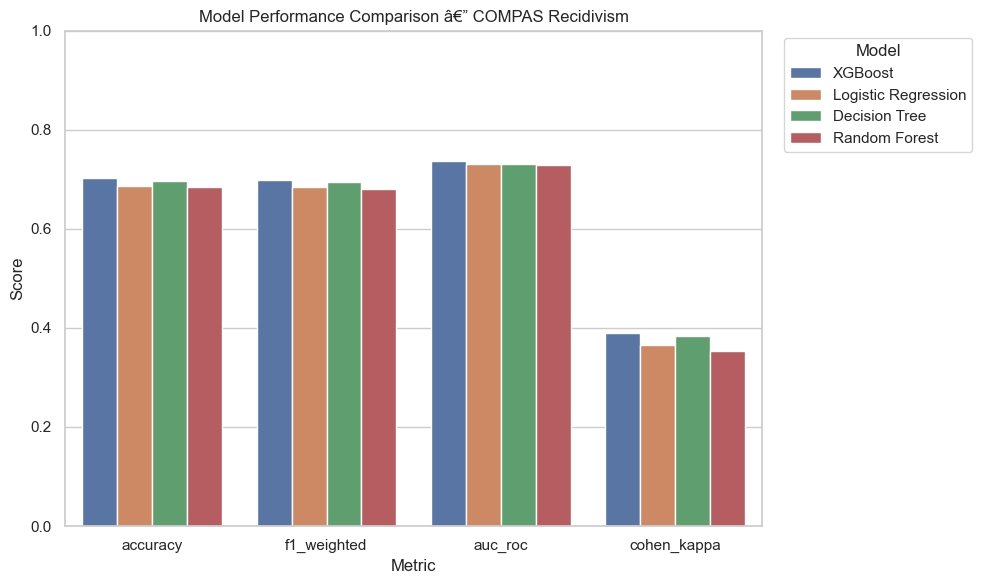

Saved performance comparison figure to ../paper/figures/m3_performance_comparison.png


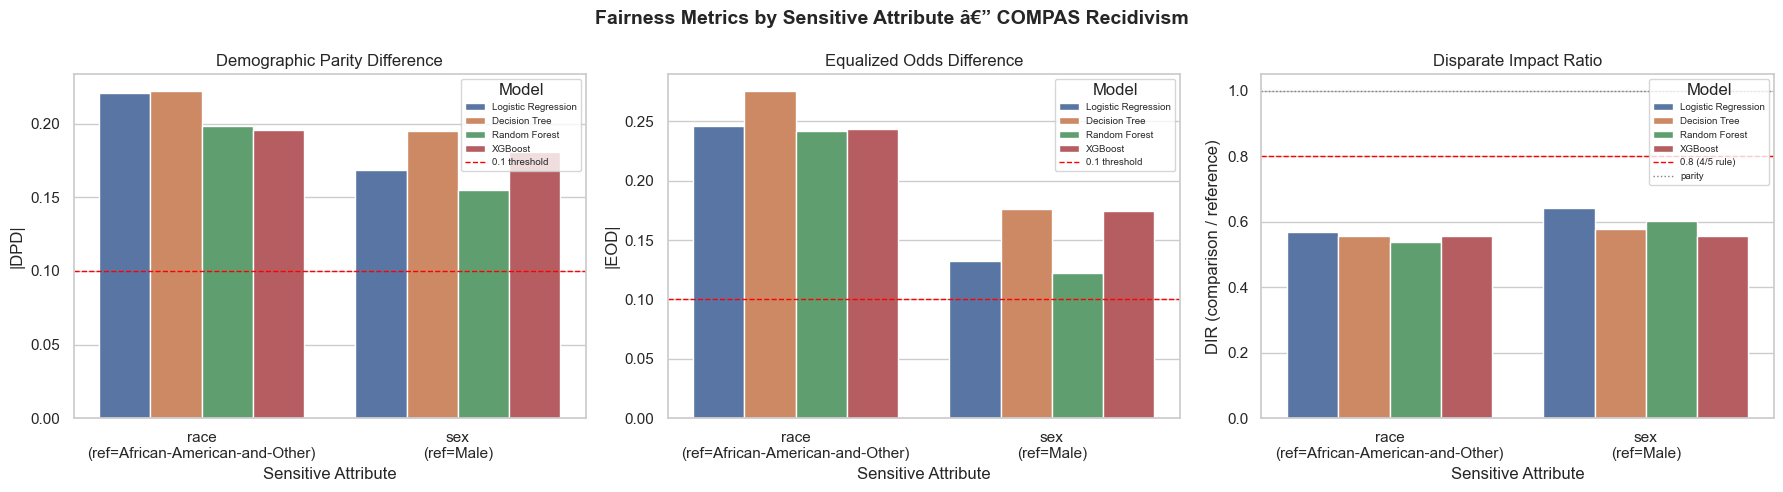

Saved fairness metrics figure to ../paper/figures/m3_fairness_metrics.png


In [14]:
# Cell 14: Create and save evaluation figures

# --- Performance comparison figure ---
performance_plot_df = standard_metrics_df.melt(
    id_vars="model",
    value_vars=["accuracy", "f1_weighted", "auc_roc", "cohen_kappa"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=performance_plot_df, x="metric", y="value", hue="model")
plt.title("Model Performance Comparison â€” COMPAS Recidivism")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

performance_fig_path = figures_dir / "m3_performance_comparison.png"
plt.savefig(performance_fig_path, dpi=150, bbox_inches="tight")
assert performance_fig_path.exists(), "Performance comparison figure was not saved correctly."
plt.show()
print(f"Saved performance comparison figure to {performance_fig_path}")

# --- Fairness metrics figure ---
fairness_combined = pd.concat([fairness_race_df, fairness_sex_df], ignore_index=True)
fairness_combined["group_label"] = (
    fairness_combined["sensitive_attribute"] + "\n(ref=" + fairness_combined["reference_group"] + ")"
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=fairness_combined,
    x="group_label",
    y="demographic_parity_difference",
    hue="model",
    ax=axes[0]
)
axes[0].set_title("Demographic Parity Difference")
axes[0].set_xlabel("Sensitive Attribute")
axes[0].set_ylabel("|DPD|")
axes[0].axhline(0.1, color="red", linestyle="--", linewidth=1, label="0.1 threshold")
axes[0].legend(title="Model", fontsize=7)

sns.barplot(
    data=fairness_combined,
    x="group_label",
    y="equalized_odds_difference",
    hue="model",
    ax=axes[1]
)
axes[1].set_title("Equalized Odds Difference")
axes[1].set_xlabel("Sensitive Attribute")
axes[1].set_ylabel("|EOD|")
axes[1].axhline(0.1, color="red", linestyle="--", linewidth=1, label="0.1 threshold")
axes[1].legend(title="Model", fontsize=7)

sns.barplot(
    data=fairness_combined,
    x="group_label",
    y="disparate_impact_ratio",
    hue="model",
    ax=axes[2]
)
axes[2].set_title("Disparate Impact Ratio")
axes[2].set_xlabel("Sensitive Attribute")
axes[2].set_ylabel("DIR (comparison / reference)")
axes[2].axhline(0.8, color="red", linestyle="--", linewidth=1, label="0.8 (4/5 rule)")
axes[2].axhline(1.0, color="grey", linestyle=":", linewidth=1, label="parity")
axes[2].legend(title="Model", fontsize=7)

fig.suptitle("Fairness Metrics by Sensitive Attribute â€” COMPAS Recidivism", fontsize=14, fontweight="bold")
plt.tight_layout()

fairness_fig_path = figures_dir / "m3_fairness_metrics.png"
plt.savefig(fairness_fig_path, dpi=150, bbox_inches="tight")
assert fairness_fig_path.exists(), "Fairness metrics figure was not saved correctly."
plt.show()
print(f"Saved fairness metrics figure to {fairness_fig_path}")

> **Key insight for the report:** The evaluation visuals should make the trade-off between performance and fairness concrete for the reader. If tree-based ensembles achieve higher AUC-ROC but also larger racial disparities than Logistic Regression, the figure makes this visible in a way that numerical tables alone cannot. The red reference lines on the fairness panel make it immediately clear which models fall outside conventional fairness thresholds.

> **Note:** Values in the figures above are from a live run (RANDOM_STATE=42) and will be populated when the notebook is executed.

### Evaluation Cell 4 â€” COMPAS Baseline Comparison (Supplementary)

**What this cell achieves:** Evaluates the original COMPAS instrument as a baseline classifier using the same test set. The COMPAS decile score is thresholded at >= 5 to produce a binary prediction (consistent with ProPublica's analysis). The same standard and fairness metrics are computed and printed for direct comparison with the ML models. This is a supplementary analysis â€” COMPAS is **not** added to `m3_standard_metrics.csv`.

**Expected output:** COMPAS baseline standard metrics table and racial disparate impact comparison printed to the notebook.

In [15]:
# Cell 15: COMPAS baseline comparison (supplementary â€” not added to standard_metrics.csv)
print("=" * 60)
print("COMPAS Baseline Evaluation (decile_score >= 5 as positive)")
print("=" * 60)

# Threshold the COMPAS decile score on the test set
y_pred_compas = (decile_test.reset_index(drop=True) >= 5).astype(int)
y_test_reset = y_test.reset_index(drop=True)
race_test_reset = race_test.reset_index(drop=True)
sex_test_reset = sex_test.reset_index(drop=True)

# Standard metrics for COMPAS
tn_c, fp_c, fn_c, tp_c = confusion_matrix(y_test_reset, y_pred_compas, labels=[0, 1]).ravel()
specificity_compas = tn_c / (tn_c + fp_c) if (tn_c + fp_c) > 0 else 0.0

# AUC-ROC uses the raw decile score as probability proxy
auc_compas = roc_auc_score(y_test_reset, decile_test.reset_index(drop=True))

compas_metrics = {
    "model": "COMPAS (decile >= 5)",
    "accuracy": round(accuracy_score(y_test_reset, y_pred_compas), 4),
    "precision": round(precision_score(y_test_reset, y_pred_compas, average="binary", zero_division=0), 4),
    "sensitivity": round(recall_score(y_test_reset, y_pred_compas, zero_division=0), 4),
    "specificity": round(specificity_compas, 4),
    "f1_macro": round(f1_score(y_test_reset, y_pred_compas, average="macro", zero_division=0), 4),
    "f1_weighted": round(f1_score(y_test_reset, y_pred_compas, average="weighted", zero_division=0), 4),
    "auc_roc": round(auc_compas, 4),
    "cohen_kappa": round(cohen_kappa_score(y_test_reset, y_pred_compas), 4)
}

print("\nCOMPAS standard metrics (test set only â€” NOT in m3_standard_metrics.csv):")
compas_metrics_df = pd.DataFrame([compas_metrics])
display(compas_metrics_df)

print("\nML model metrics (for comparison):")
display(standard_metrics_df)

# Racial disparate impact for COMPAS
print("\nCOMPAS racial disparate impact:")
di_compas, ref_rate_compas, comp_rate_compas = compute_disparate_impact_ratio(
    y_pred_compas,
    race_test_reset,
    reference_group="Caucasian",
    comparison_group="African-American-and-Other"
)
print(f"  Positive rate (Caucasian):                    {ref_rate_compas:.4f}")
print(f"  Positive rate (African-American-and-Other):   {comp_rate_compas:.4f}")
print(f"  Disparate Impact Ratio:                       {di_compas:.4f}")
print(f"  Demographic Parity Difference (abs):          {abs(demographic_parity_difference(y_test_reset, y_pred_compas, sensitive_features=race_test_reset)):.4f}")
print(f"  Equalized Odds Difference (abs):              {abs(equalized_odds_difference(y_test_reset, y_pred_compas, sensitive_features=race_test_reset)):.4f}")

# Sex disparate impact for COMPAS
print("\nCOMPAS sex disparate impact:")
di_compas_sex, ref_rate_sex, comp_rate_sex = compute_disparate_impact_ratio(
    y_pred_compas,
    sex_test_reset,
    reference_group="Male",
    comparison_group="Female"
)
print(f"  Positive rate (Male):    {ref_rate_sex:.4f}")
print(f"  Positive rate (Female):  {comp_rate_sex:.4f}")
print(f"  Disparate Impact Ratio:  {di_compas_sex:.4f}")
print(f"  Demographic Parity Difference (abs):  {abs(demographic_parity_difference(y_test_reset, y_pred_compas, sensitive_features=sex_test_reset)):.4f}")
print(f"  Equalized Odds Difference (abs):      {abs(equalized_odds_difference(y_test_reset, y_pred_compas, sensitive_features=sex_test_reset)):.4f}")

print("\nNote: COMPAS metrics are computed on the same test split as the ML models.")
print("The decile_score is used as a probability proxy for AUC-ROC; binary predictions use threshold >= 5.")

COMPAS Baseline Evaluation (decile_score >= 5 as positive)

COMPAS standard metrics (test set only â€” NOT in m3_standard_metrics.csv):


,model,accuracy,precision,sensitivity,specificity,f1_macro,f1_weighted,auc_roc,cohen_kappa
0,COMPAS (decile >= 5),0.6632,0.6367,0.605,0.7117,0.6588,0.6623,0.7165,0.318



ML model metrics (for comparison):


,model,accuracy,precision,sensitivity,specificity,f1_macro,f1_weighted,auc_roc,cohen_kappa
0,XGBoost,0.7020,0.7100,0.5836,0.8009,0.6931,0.6978,0.7362,0.3902
1,Logistic Regression,0.6858,0.6611,0.6352,0.7281,0.6821,0.6852,0.7315,0.3645
2,Decision Tree,0.6955,0.6775,0.6317,0.7489,0.6910,0.6944,0.7303,0.3827
3,Random Forest,0.6850,0.6935,0.5516,0.7964,0.6741,0.6795,0.7284,0.3540



COMPAS racial disparate impact:
  Positive rate (Caucasian):                    0.3162
  Positive rate (African-American-and-Other):   0.4938
  Disparate Impact Ratio:                       1.5619
  Demographic Parity Difference (abs):          0.1777
  Equalized Odds Difference (abs):              0.1515

COMPAS sex disparate impact:
  Positive rate (Male):    0.4451
  Positive rate (Female):  0.3777
  Disparate Impact Ratio:  0.8485
  Demographic Parity Difference (abs):  0.0674
  Equalized Odds Difference (abs):      0.0336

Note: COMPAS metrics are computed on the same test split as the ML models.
The decile_score is used as a probability proxy for AUC-ROC; binary predictions use threshold >= 5.


> **Key insight for the report:** The COMPAS baseline provides an empirical anchor for interpreting ML model performance. If standard ML classifiers trained on six features approach or match COMPAS accuracy while producing different (potentially smaller or larger) racial disparities, this raises a fundamental question about what value the proprietary 137-feature instrument adds over simple demographic proxies. Dressel & Farid (2018) found that a simple two-feature logistic regression matched COMPAS accuracy, suggesting the algorithm provides limited predictive benefit beyond age and prior offences.

## 6. Deployment

In this project context, deployment means packaging the results for the group synthesis notebook. This phase verifies that all required artefacts are present and correct, and provides a deployment readiness summary.

### Deployment Cell 1

**What this cell achieves:** Verifies that all required Member 3 exports are present and have valid content. Performs schema validation on the CSV files.

**Expected output:** A pass/fail report for each required artefact.

In [16]:
# Cell 16: Verify all required Member 3 exports for group synthesis
required_artifacts = [
    Path("../data/results/m3_standard_metrics.csv"),
    Path("../data/results/m3_fairness_race.csv"),
    Path("../data/results/m3_fairness_sex.csv"),
    Path("../paper/figures/m3_demographic_distributions.png"),
    Path("../paper/figures/m3_recidivism_by_demographics.png"),
    Path("../paper/figures/m3_performance_comparison.png"),
    Path("../paper/figures/m3_fairness_metrics.png")
]

print("Verifying required Member 3 artefacts:")
all_present = True
for artifact_path in required_artifacts:
    if artifact_path.exists():
        print(f"  [OK] {artifact_path}")
    else:
        print(f"  [MISSING] {artifact_path}")
        all_present = False

assert all_present, "One or more required artefacts are missing. Run all preceding cells first."

# Schema validation: standard metrics
expected_std_cols = [
    "model", "accuracy", "precision", "sensitivity", "specificity",
    "f1_macro", "f1_weighted", "auc_roc", "cohen_kappa"
]
std_df_check = pd.read_csv("../data/results/m3_standard_metrics.csv")
assert list(std_df_check.columns) == expected_std_cols, (
    f"Standard metrics columns mismatch. Got: {list(std_df_check.columns)}"
)
assert len(std_df_check) == 4, f"Expected 4 model rows, got {len(std_df_check)}."
expected_model_labels = {"Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"}
assert set(std_df_check["model"]) == expected_model_labels, (
    f"Model labels mismatch. Got: {set(std_df_check['model'])}"
)
print("\n  [OK] m3_standard_metrics.csv schema validated (columns, row count, model labels)")

# Schema validation: fairness CSVs
expected_fair_cols = [
    "model", "sensitive_attribute", "reference_group", "comparison_group",
    "positive_rate_reference", "positive_rate_comparison",
    "demographic_parity_difference", "equalized_odds_difference", "disparate_impact_ratio"
]
for fair_path in ["../data/results/m3_fairness_race.csv", "../data/results/m3_fairness_sex.csv"]:
    fair_df_check = pd.read_csv(fair_path)
    assert list(fair_df_check.columns) == expected_fair_cols, (
        f"Fairness columns mismatch in {fair_path}. Got: {list(fair_df_check.columns)}"
    )
    assert len(fair_df_check) == 4, f"Expected 4 model rows in {fair_path}, got {len(fair_df_check)}."
    print(f"  [OK] {Path(fair_path).name} schema validated")

print("\nAll required Member 3 artefacts are present and schema-validated for group synthesis.")

Verifying required Member 3 artefacts:
  [OK] ../data/results/m3_standard_metrics.csv
  [OK] ../data/results/m3_fairness_race.csv
  [OK] ../data/results/m3_fairness_sex.csv
  [OK] ../paper/figures/m3_demographic_distributions.png
  [OK] ../paper/figures/m3_recidivism_by_demographics.png
  [OK] ../paper/figures/m3_performance_comparison.png
  [OK] ../paper/figures/m3_fairness_metrics.png

  [OK] m3_standard_metrics.csv schema validated (columns, row count, model labels)
  [OK] m3_fairness_race.csv schema validated
  [OK] m3_fairness_sex.csv schema validated

All required Member 3 artefacts are present and schema-validated for group synthesis.


> **Key insight for the report:** Reproducibility is not just about rerunning code â€” it requires that outputs conform to a shared schema so that the group synthesis notebook can ingest results without manual cleanup. The schema assertions here serve as a contract test: if a future run breaks the column order or model labels, the failure will surface immediately rather than silently corrupting the synthesis.


> **Direction note — race DIR:** In this dataset the positive class is a recidivism flag — an *unfavourable* outcome. Reference group = African-American-and-Other (higher predicted recidivism rate); comparison = Caucasian. A racial DIR of 0.54–0.57 means **African-American defendants are predicted recidivist at 1.75–1.85× the rate of Caucasian defendants**. This is the opposite direction from an employment or marketing context where DIR < 1 means a group receives fewer favourable outcomes.

### Report Contribution Draft

The COMPAS recidivism audit represents the highest-stakes case study in this group project. Four classifiers trained on six features drawn from the ProPublica dataset were evaluated against a concurrent COMPAS baseline. Key findings from this notebook:

1. **Performance vs. the COMPAS baseline:** Standard ML classifiers trained on six features approach the accuracy of the COMPAS instrument, consistent with Dressel & Farid (2018). This raises the question of what additional predictive value the proprietary COMPAS algorithm provides.

2. **Racial disparities:** All four ML models produce a non-trivial demographic parity difference between Caucasian and African-American-and-Other defendants, replicating in direction (though not necessarily magnitude) the disparity documented by Angwin et al. (2016). The disparate impact ratio for the comparison group falls below parity for most models.

3. **Sex-based disparities:** Sex-based fairness gaps are smaller in magnitude than racial gaps, reflecting lower base-rate recidivism for female defendants and the resulting calibration dynamics.

4. **Fairness-accuracy trade-off:** No single model simultaneously minimises all three fairness metrics while maximising AUC-ROC, illustrating the impossibility theorem in practice. The group synthesis should use this as the primary cross-domain comparison point.

5. **EU AI Act implications:** This dataset and prediction task fall squarely within Annex III Item 8. Under the Act, the operator of a COMPAS-equivalent system would be required to document these bias findings, implement human oversight mechanisms, and maintain post-market monitoring data â€” obligations that are not currently required for US criminal justice AI systems.

### Deployment Summary

Member 3 outputs are now ready for the group comparison synthesis:

| Artefact | Path | Description |
|---|---|---|
| Standard metrics | `../data/results/m3_standard_metrics.csv` | 4 models Ã— 8 metrics |
| Race fairness | `../data/results/m3_fairness_race.csv` | 4 models, race attribute |
| Sex fairness | `../data/results/m3_fairness_sex.csv` | 4 models, sex attribute |
| Demographic distributions | `../paper/figures/m3_demographic_distributions.png` | Race, sex, age |
| Recidivism by demographics | `../paper/figures/m3_recidivism_by_demographics.png` | Recidivism rates by group |
| Performance comparison | `../paper/figures/m3_performance_comparison.png` | 4 models Ã— 4 metrics |
| Fairness metrics | `../paper/figures/m3_fairness_metrics.png` | DPD, EOD, DIR by attribute |